In [1]:
#Import all packages
import os
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import folium
import contextily as ctx
import scipy.stats
import scipy.interpolate
import tqdm
from pathlib import Path
import xarray as xr
import skgstat as skg
import seaborn as sns
import pysal
from pysal.explore import esda
from pysal.lib import weights
from splot.esda import moran_scatterplot
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib_scalebar.scalebar import ScaleBar
import rasterio
from rasterio.plot import show

/opt/conda/lib/python3.11/site-packages/spaghetti/network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


In [2]:
# ==========================================================
# FILE PATHS
# ==========================================================

DATA = Path("/home/jovyan/Society_of_Bouy_Cowboys/Data")

NETCDF = DATA / "NET_CDF"
ICE = DATA / "Ice_edge"
SAT = DATA / "SAT_GeoTiff"

raster_file = SAT / "IcyCape_201911201739_S1B_EW_50m.tif"
edge_file = ICE / "ice_edge_11201739.geojson"


# buoy files
moor_files = {
    "S1P1": NETCDF / "S1P1.nc",
    "S1P2": NETCDF / "S1P2.nc",
    "S1P3": NETCDF / "S1P3.nc",
    "S1A1": NETCDF / "S1A1.nc"
}


# CRS used for ALL spatial analysis
analysis_crs = "EPSG:6096"

In [3]:
# ==========================================================
# HELPER FUNCTION
# Extract representative lat/lon for each buoy
# ==========================================================

def get_mooring_latlon(ncfile):
    ds = xr.open_dataset(ncfile)

    lat = np.asarray(ds["lat_lagrangian"]).astype(float).ravel()
    lon = np.asarray(ds["lon_lagrangian"]).astype(float).ravel()

    good = np.isfinite(lat) & np.isfinite(lon)

    lat = lat[good]
    lon = lon[good]

    if len(lat) == 0:
        raise ValueError(f"No valid lat/lon found in {ncfile}")

    # median gives robust representative location
    return np.median(lat), np.median(lon)

In [4]:
# ==========================================================
# BUILD BUOY TABLE
# ==========================================================
rows = []

for name, fn in moor_files.items():
    lat, lon = get_mooring_latlon(fn)
    rows.append({
        "source": name,
        "lat": lat,
        "lon": lon
    })

moor_df = pd.DataFrame(rows)

In [5]:
# ==========================================================
# BUOY GEO DATAFRAME
# ==========================================================

moor_gdf = gpd.GeoDataFrame(
    moor_df,
    geometry=gpd.points_from_xy(moor_df["lon"], moor_df["lat"]),
    crs="EPSG:4326"
)

# convert buoys into analysis CRS
moor_6096 = moor_gdf.to_crs(analysis_crs)


print("Buoys in analysis CRS:")
print(moor_6096[["source","geometry"]])

Buoys in analysis CRS:
  source                          geometry
0   S1P1  POINT (14610474.141 6687624.269)
1   S1P2  POINT (14607231.799 6692899.397)
2   S1P3  POINT (14604523.024 6697825.303)
3   S1A1   POINT (14601312.025 6702930.59)


In [6]:
# ==========================================================
# LOAD ICE EDGE
# ==========================================================
edge_gdf = gpd.read_file(edge_file)

print("Edge CRS from file:", edge_gdf.crs)
print("Edge bounds:", edge_gdf.total_bounds)

with rasterio.open(raster_file) as src:
    print("raster bounds:", src.bounds)
    print("raster CRS:", src.crs)

Edge CRS from file: EPSG:32604
Edge bounds: [   4586.15203503 -140207.18467934  200032.39801059  -57337.97638571]
raster bounds: BoundingBox(left=0.0, bottom=-148074.0, right=202101.0, top=0.0)
raster CRS: None


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

with rasterio.open(raster_file) as src:
    show(src, ax=ax, cmap="gray")

edge_gdf.plot(ax=ax, color="cyan", linewidth=2)

ax.set_title("Click control points, then press Enter")
scene_pts = plt.ginput(n=-1, timeout=0)
plt.show()

scene_pts = np.array(scene_pts)
scene_pts

Raster bounds: BoundingBox(left=0.0, bottom=-148074.0, right=202101.0, top=0.0)
Raster CRS: None


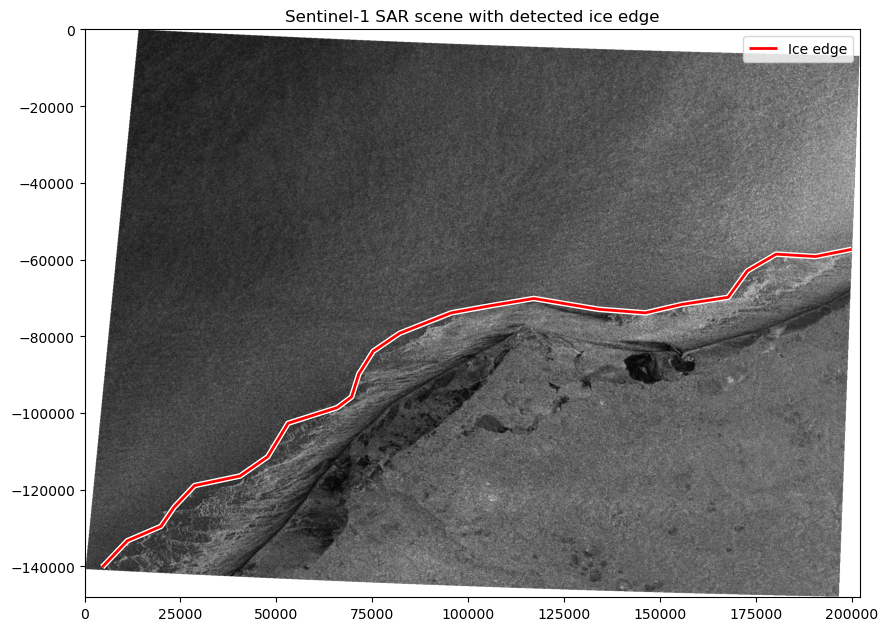

In [13]:
# ==========================================================
# PLOT RASTER + ICE EDGE
# ==========================================================

fig, ax = plt.subplots(figsize=(10,8))

with rasterio.open(raster_file) as src:

   # print("Raster bounds:", src.bounds)
   # print("Raster CRS:", src.crs)

    show(src, ax=ax, cmap="gray")


# edge already matches raster coordinate system
edge_gdf.plot(
    ax=ax,
    color="white",
    linewidth=4
)

edge_gdf.plot(
    ax=ax,
    color="red",
    linewidth=2,
    label="Ice edge"
)

ax.set_title("Sentinel-1 SAR scene with detected ice edge")

ax.legend()

In [15]:
aux_file = DATA / "SAT_GeoTiff/IcyCape_201911201739_S1B_EW_50m.tif.aux.xml"

with open(aux_file, "r", encoding="utf-8", errors="ignore") as f:
    text = f.read()

print(text[:5000])

<PAMDataset>
  <PAMRasterBand band="1">
    <Histograms>
      <HistItem>
        <HistMin>0.0009196509052657617</HistMin>
        <HistMax>0.01391557323237573</HistMax>
        <BucketCount>249320</BucketCount>
        <IncludeOutOfRange>0</IncludeOutOfRange>
        <Approximate>1</Approximate>
        <HistCounts>1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|

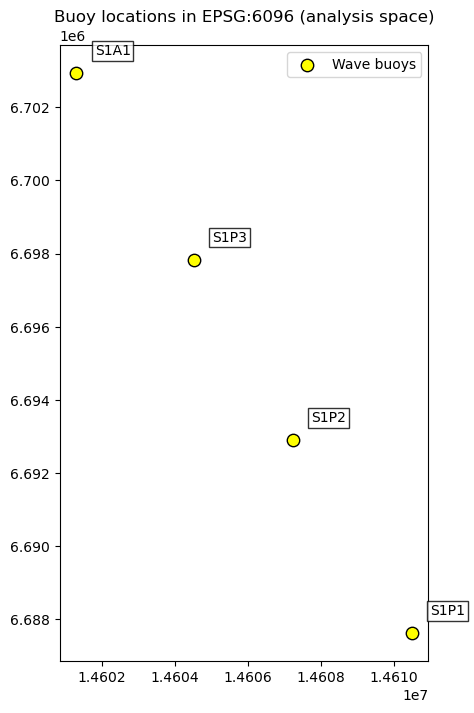

In [14]:
# ==========================================================
# OPTIONAL: PLOT BUOYS + ICE EDGE IN ANALYSIS SPACE
# ==========================================================

# This figure is for geometry calculations,
# not raster overlay.

edge_6096 = None

try:
    edge_6096 = edge_gdf.to_crs(analysis_crs)
except:
    print("Edge cannot be converted to analysis CRS (scene coords).")


fig, ax = plt.subplots(figsize=(8,8))

moor_6096.plot(
    ax=ax,
    color="yellow",
    edgecolor="black",
    markersize=80,
    label="Wave buoys"
)

for x, y, label in zip(
    moor_6096.geometry.x,
    moor_6096.geometry.y,
    moor_6096["source"]
):

    ax.text(
        x + 500,
        y + 500,
        label,
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8, pad=2)
    )


ax.set_title("Buoy locations in EPSG:6096 (analysis space)")

ax.set_aspect("equal")

ax.legend()